In [10]:
# Eigenschaften der AS in Dictionary anlegen


amino_acid_properties = {
    'A': {'hydrophobicity': 1.8, 'charge': 0, 'mass': 89.09, 'polarity': 8.1},
    'R': {'hydrophobicity': -4.5, 'charge': +1, 'mass': 174.20, 'polarity': 10.5},
    'N': {'hydrophobicity': -3.5, 'charge': 0, 'mass': 132.12, 'polarity': 11.6},
    'D': {'hydrophobicity': -3.5, 'charge': -1, 'mass': 133.10, 'polarity': 13.0},
    'C': {'hydrophobicity': 2.5, 'charge': 0, 'mass': 121.15, 'polarity': 5.5},
    'Q': {'hydrophobicity': -3.5, 'charge': 0, 'mass': 146.15, 'polarity': 10.5},
    'E': {'hydrophobicity': -3.5, 'charge': -1, 'mass': 147.13, 'polarity': 12.3},
    'G': {'hydrophobicity': -0.4, 'charge': 0, 'mass': 75.07, 'polarity': 9.0},
    'H': {'hydrophobicity': -3.2, 'charge': +1, 'mass': 155.16, 'polarity': 10.4},
    'I': {'hydrophobicity': 4.5, 'charge': 0, 'mass': 131.17, 'polarity': 5.2},
    'L': {'hydrophobicity': 3.8, 'charge': 0, 'mass': 131.17, 'polarity': 4.9},
    'K': {'hydrophobicity': -3.9, 'charge': +1, 'mass': 146.19, 'polarity': 11.3},
    'M': {'hydrophobicity': 1.9, 'charge': 0, 'mass': 149.21, 'polarity': 5.7},
    'F': {'hydrophobicity': 2.8, 'charge': 0, 'mass': 165.19, 'polarity': 5.2},
    'P': {'hydrophobicity': -1.6, 'charge': 0, 'mass': 115.13, 'polarity': 8.0},
    'S': {'hydrophobicity': -0.8, 'charge': 0, 'mass': 105.09, 'polarity': 9.2},
    'T': {'hydrophobicity': -0.7, 'charge': 0, 'mass': 119.12, 'polarity': 8.6},
    'W': {'hydrophobicity': -0.9, 'charge': 0, 'mass': 204.23, 'polarity': 5.4},
    'Y': {'hydrophobicity': -1.3, 'charge': 0, 'mass': 181.19, 'polarity': 6.2},
    'V': {'hydrophobicity': 4.2, 'charge': 0, 'mass': 117.15, 'polarity': 5.9}
}

In [11]:
import pandas as pd

# Aminosäure-Eigenschaften (Dictionary musst du vorher definiert haben!)
amino_acids = list(amino_acid_properties.keys())

# Funktion zur Prüfung, ob Sequenz gültig ist
def is_valid_sequence(seq):
    return isinstance(seq, str) and seq.strip().lower() not in ["", "nan", "none"]

# Liste deiner TSV-Dateien
dateien = [
    "human_cdr_seq.tsv",
    "influenza_cdr_seq.tsv",
    "sars_cov2_cdr_seq.tsv"
]

# Durch alle Dateien gehen
for datei in dateien:
    print(f"\n Verarbeite und bereinige Datei: {datei}")
    df = pd.read_csv(datei, sep="\t")

    # CDR-Spalten prüfen und bereinigen
    for cdr in ['CDR_H1', 'CDR_H2', 'CDR_H3']:
        if cdr in df.columns:
            # Nur gültige Sequenzen behalten
            df = df[df[cdr].apply(is_valid_sequence)]
            print(f"   {cdr}: {len(df)} gültige Sequenzen")

            # Aminosäuren zählen und neue Spalten hinzufügen
            for index, row in df.iterrows():
                seq = row[cdr]
                for aa in amino_acids:
                    count = seq.count(aa)
                    df.loc[index, f'{cdr}_count_{aa}'] = count
        else:
            print(f"   Spalte {cdr} fehlt in {datei}")

    # Direkt die Originaldatei überschreiben
    df.to_csv(datei, sep="\t", index=False)
    print(f"   Datei aktualisiert und gespeichert: {datei}")



 Verarbeite und bereinige Datei: human_cdr_seq.tsv
   CDR_H1: 379 gültige Sequenzen
   CDR_H2: 379 gültige Sequenzen
   CDR_H3: 379 gültige Sequenzen
   Datei aktualisiert und gespeichert: human_cdr_seq.tsv

 Verarbeite und bereinige Datei: influenza_cdr_seq.tsv
   CDR_H1: 100 gültige Sequenzen
   CDR_H2: 100 gültige Sequenzen
   CDR_H3: 100 gültige Sequenzen
   Datei aktualisiert und gespeichert: influenza_cdr_seq.tsv

 Verarbeite und bereinige Datei: sars_cov2_cdr_seq.tsv
   CDR_H1: 378 gültige Sequenzen
   CDR_H2: 378 gültige Sequenzen
   CDR_H3: 378 gültige Sequenzen
   Datei aktualisiert und gespeichert: sars_cov2_cdr_seq.tsv


Erklärung:

1. Vorbereitung

- amino_acids ist eine Liste aller Aminosäuren-Buchstaben (z. B. 'A', 'R', 'N', …).

- is_valid_sequence ist eine Funktion, die prüft, ob eine Sequenz gültig ist (kein "nan", "none" oder leer)

2. Dateien, die verarbeitet werden

dateien = [
    "human_cdr_seq.tsv",
    "influenza_cdr_seq.tsv",
    "sars_cov2_cdr_seq.tsv"
]
= TSV-Dateien werden nacheinander verarbeitet.

3. Für jede Datei wird gemacht:

a. Einlesen der Datei    
- df = pd.read_csv(datei, sep="\t")


b. Für jede CDR-Region (CDR_H1, CDR_H2, CDR_H3):
- Nur gültige Sequenzen behalten (is_valid_sequence)
- Aminosäuren zählen: Für jede gültige Sequenz wird gezählt, wie oft jede Aminosäure vorkommt.
→ Die Zählwerte werden in neuen Spalten gespeichert, z. B. CDR_H3_count_A.

c. Ergebnis speichern
- df.to_csv(f"bereinigt_{datei}", sep="\t", index=False)

 Die bereinigte und erweiterte Tabelle wird unter einem neuen Namen gespeichert

In [12]:
for datei in dateien:
    print(f"\nBerechne mittlere Eigenschaften für: {datei}")
    df = pd.read_csv(datei, sep="\t")

    for cdr in ['CDR_H1', 'CDR_H2', 'CDR_H3']:
        if cdr in df.columns:
            for index, row in df.iterrows():
                sequence = row[cdr]

                if isinstance(sequence, str):
                    hydrophobicities = []
                    charges = []
                    polarities = []
                    masses = []

                    for aa in sequence:
                        if aa in amino_acid_properties:
                            hydrophobicities.append(amino_acid_properties[aa]['hydrophobicity'])
                            charges.append(amino_acid_properties[aa]['charge'])
                            polarities.append(amino_acid_properties[aa]['polarity'])
                            masses.append(amino_acid_properties[aa]['mass'])
                        else:
                            print(f" Unbekannte Aminosäure '{aa}' in {cdr}, Zeile {index+1}")

                    # Mittelwerte berechnen
                    if hydrophobicities:
                        df.loc[index, f'{cdr}_mean_hydrophobicity'] = sum(hydrophobicities) / len(hydrophobicities)
                    if charges:
                        df.loc[index, f'{cdr}_mean_charge'] = sum(charges) / len(charges)
                    if polarities:
                        df.loc[index, f'{cdr}_mean_polarity'] = sum(polarities) / len(polarities)
                    if masses:
                        df.loc[index, f'{cdr}_mean_mass'] = sum(masses) / len(masses)
                else:
                    print(f" Ungültige {cdr}-Sequenz in Zeile {index+1} (Typ: {type(sequence)})")

    # Speichert direkt zurück in die ursprüngliche Datei
    df.to_csv(datei, sep="\t", index=False)
    print(f"Eigenschaften direkt in {datei} gespeichert (Originaldatei erweitert)")



Berechne mittlere Eigenschaften für: human_cdr_seq.tsv
Eigenschaften direkt in human_cdr_seq.tsv gespeichert (Originaldatei erweitert)

Berechne mittlere Eigenschaften für: influenza_cdr_seq.tsv
Eigenschaften direkt in influenza_cdr_seq.tsv gespeichert (Originaldatei erweitert)

Berechne mittlere Eigenschaften für: sars_cov2_cdr_seq.tsv
Eigenschaften direkt in sars_cov2_cdr_seq.tsv gespeichert (Originaldatei erweitert)


In [13]:
# CDR-Längen berechnen und direkt in bestehende Dateien schreiben

cdrs = ["CDR_H1", "CDR_H2", "CDR_H3"]

for datei in dateien:
    print(f"\nBerechne CDR-Längen für: {datei}")
    df = pd.read_csv(datei, sep="\t")

    for cdr in cdrs:
        if cdr in df.columns:
            print(f"🔍  → Bearbeite: {cdr}")
            df = df[df[cdr].apply(is_valid_sequence)]  # Nur gültige Sequenzen
            df[f'{cdr.lower()}_length'] = df[cdr].apply(len)
        else:
            print(f" {cdr} nicht vorhanden in {datei}")

    df.to_csv(datei, sep="\t", index=False)
    print(f"Aktualisiert gespeichert: {datei}")



Berechne CDR-Längen für: human_cdr_seq.tsv
🔍  → Bearbeite: CDR_H1
🔍  → Bearbeite: CDR_H2
🔍  → Bearbeite: CDR_H3
Aktualisiert gespeichert: human_cdr_seq.tsv

Berechne CDR-Längen für: influenza_cdr_seq.tsv
🔍  → Bearbeite: CDR_H1
🔍  → Bearbeite: CDR_H2
🔍  → Bearbeite: CDR_H3
Aktualisiert gespeichert: influenza_cdr_seq.tsv

Berechne CDR-Längen für: sars_cov2_cdr_seq.tsv
🔍  → Bearbeite: CDR_H1
🔍  → Bearbeite: CDR_H2
🔍  → Bearbeite: CDR_H3
Aktualisiert gespeichert: sars_cov2_cdr_seq.tsv


In [14]:
#kontrolle

# Datensatz laden (z. B. SARS-CoV-2)
df = pd.read_csv("sars_cov2_cdr_seq.tsv", sep="\t")

# Nur die ersten 5 Zeilen anzeigen
df.head(5)


,pdb,heavy_chain,CDR_H3,CDR_H2,CDR_H1,CDR_H1_mean_hydrophobicity,CDR_H1_mean_charge,CDR_H1_mean_polarity,CDR_H1_mean_mass,CDR_H2_mean_hydrophobicity,...,CDR_H3_count_F,CDR_H3_count_P,CDR_H3_count_S,CDR_H3_count_T,CDR_H3_count_W,CDR_H3_count_Y,CDR_H3_count_V,cdr_h1_length,cdr_h2_length,cdr_h3_length
0,9cci,B,TFGTYYDNTEDWFFDF,YGGDSD,GYSFSSF,0.214286,0.000000,7.600000,128.844286,-1.65,...,4.0,0.0,0.0,3.0,1.0,2.0,0.0,7,6,16
1,9ccj,H,LPLGERIDY,YYSGT,GGSINTNMY,-0.466667,0.000000,8.455556,122.240000,-0.90,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9,5,9
2,9bj2,H,HNGDPYDFWSGYNTWAGGLDV,IPFLDV,GVIFSRN,0.328571,0.142857,8.085714,128.570000,1.70,...,1.0,1.0,1.0,1.0,2.0,2.0,1.0,7,6,21
3,8z6r,E,QGDLGDWILLGY,YPGDSD,GYTFSYY,-0.428571,0.000000,7.228571,144.005714,-1.85,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,7,6,12
4,8z6s,E,QGDLGDWILLGY,YPGDSD,GYTFSYY,-0.428571,0.000000,7.228571,144.005714,-1.85,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,7,6,12


In [15]:
# schauen welxhe Spalten wir jetzt haben

# Lade den gewünschten Datensatz
df = pd.read_csv("sars_cov2_cdr_seq.tsv", sep="\t")

# Zeige alle Spaltennamen an
print(df.columns.tolist())


['pdb', 'heavy_chain', 'CDR_H3', 'CDR_H2', 'CDR_H1', 'CDR_H1_mean_hydrophobicity', 'CDR_H1_mean_charge', 'CDR_H1_mean_polarity', 'CDR_H1_mean_mass', 'CDR_H2_mean_hydrophobicity', 'CDR_H2_mean_charge', 'CDR_H2_mean_polarity', 'CDR_H2_mean_mass', 'CDR_H3_mean_hydrophobicity', 'CDR_H3_mean_charge', 'CDR_H3_mean_polarity', 'CDR_H3_mean_mass', 'CDR_H1_count_A', 'CDR_H1_count_R', 'CDR_H1_count_N', 'CDR_H1_count_D', 'CDR_H1_count_C', 'CDR_H1_count_Q', 'CDR_H1_count_E', 'CDR_H1_count_G', 'CDR_H1_count_H', 'CDR_H1_count_I', 'CDR_H1_count_L', 'CDR_H1_count_K', 'CDR_H1_count_M', 'CDR_H1_count_F', 'CDR_H1_count_P', 'CDR_H1_count_S', 'CDR_H1_count_T', 'CDR_H1_count_W', 'CDR_H1_count_Y', 'CDR_H1_count_V', 'CDR_H2_count_A', 'CDR_H2_count_R', 'CDR_H2_count_N', 'CDR_H2_count_D', 'CDR_H2_count_C', 'CDR_H2_count_Q', 'CDR_H2_count_E', 'CDR_H2_count_G', 'CDR_H2_count_H', 'CDR_H2_count_I', 'CDR_H2_count_L', 'CDR_H2_count_K', 'CDR_H2_count_M', 'CDR_H2_count_F', 'CDR_H2_count_P', 'CDR_H2_count_S', 'CDR_H2_cou

In [ ]:
# Mittelwerte der Eigenschaften vergelchen von CDR H3
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Wir analysieren CDR_H3
eigenschaften = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass']

# Ergebnisse vorbereiten
frames = []
for name in ["human", "sars_cov2", "influenza"]:
    df = pd.read_csv(f"{name}_cdr_seq.tsv", sep="\t")
    df["quelle"] = name  # Herkunft der Daten
    frames.append(df)

# Kombinieren
alle = pd.concat(frames)

# Schleife durch alle Eigenschaften
for eig in eigenschaften:
    spalte = f'CDR_H3_{eig}'
    
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=alle, x='quelle', y=spalte)
    plt.title(f"Vergleich: {spalte}")
    plt.show()

    # ANOVA-Test
    human = alle[alle["quelle"] == "human"][spalte].dropna()
    sars = alle[alle["quelle"] == "sars_cov2"][spalte].dropna()
    influenza = alle[alle["quelle"] == "influenza"][spalte].dropna()
    
    f_stat, p_val = f_oneway(human, sars, influenza)
    print(f"🔬 {spalte} – ANOVA p-Wert: {p_val:.4f}")


ModuleNotFoundError: No module named 'scipy'

: 

In [ ]:
#Vergleich der Längen (cdr_h1_length, cdr_h2_length, cdr_h3_length)
#Wie lang sind die Loops bei SARS-CoV-2 im Vergleich zu Influenza/human?


for region in ["cdr_h1_length", "cdr_h2_length", "cdr_h3_length"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=alle, x='quelle', y=region)
    plt.title(f"Vergleich der Längen: {region}")
    plt.show()

    h = alle[alle["quelle"] == "human"][region].dropna()
    s = alle[alle["quelle"] == "sars_cov2"][region].dropna()
    i = alle[alle["quelle"] == "influenza"][region].dropna()
    
    f_stat, p_val = f_oneway(h, s, i)
    print(f"📏 {region} – ANOVA p-Wert: {p_val:.4f}")


NameError: name 'alle' is not defined

<Figure size 600x400 with 0 Axes>

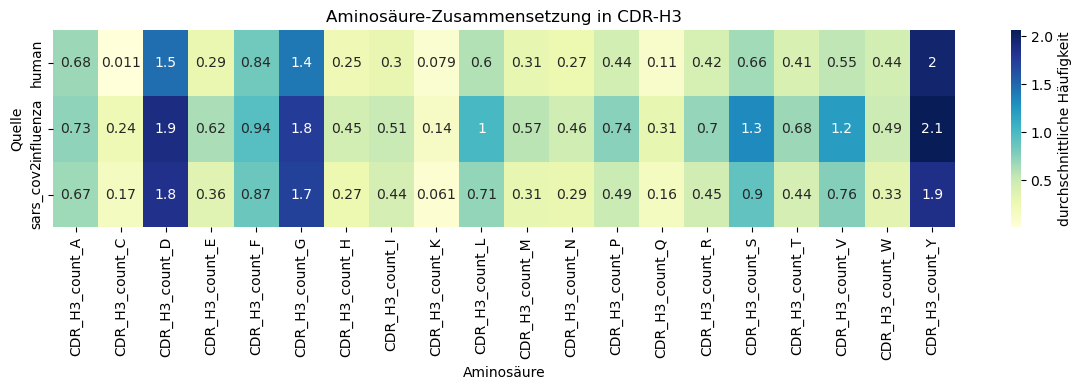

In [ ]:
# Heatmap zur Aminosäurehäufigkeit (CDR_H3)

import seaborn as sns
import matplotlib.pyplot as plt

# Dateien und Labels
dateien = {
    "human": "human_cdr_seq.tsv",
    "sars_cov2": "sars_cov2_cdr_seq.tsv",
    "influenza": "influenza_cdr_seq.tsv"
}

# Ergebnisse speichern
df_list = []

for quelle, path in dateien.items():
    df = pd.read_csv(path, sep="\t")
    
    # Nur CDR_H3-Count-Spalten auswählen
    aa_counts = df[[col for col in df.columns if col.startswith('CDR_H3_count_')]].copy()
    aa_counts['quelle'] = quelle
    df_list.append(aa_counts)

# Zusammenführen
df_all = pd.concat(df_list)

# Gruppieren und Mittelwerte berechnen
heatmap_data = df_all.groupby('quelle').mean()

# Spalten alphabetisch sortieren
heatmap_data = heatmap_data[sorted(heatmap_data.columns)]

# Plot
plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", cbar_kws={"label": "durchschnittliche Häufigkeit"})
plt.title("Aminosäure-Zusammensetzung in CDR-H3")
plt.xlabel("Aminosäure")
plt.ylabel("Quelle")
plt.tight_layout()
plt.show()


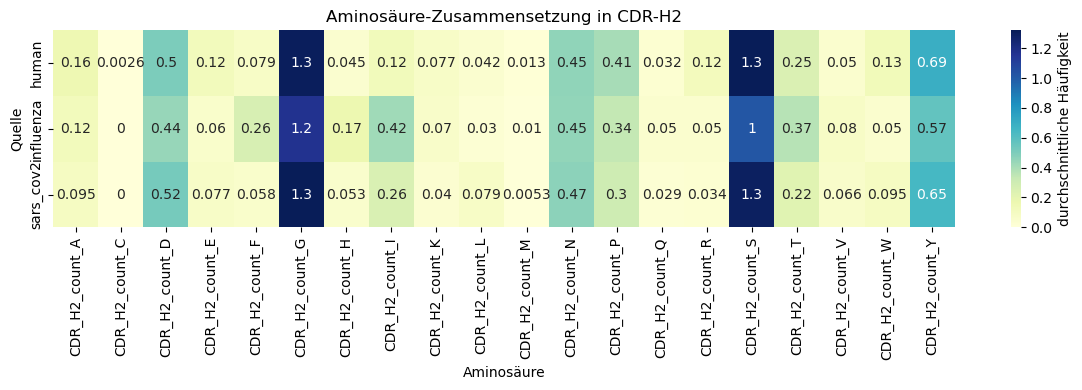

In [ ]:
#Heatmap zur Aminosäurehäufigkeit (CDR_H2)

import seaborn as sns
import matplotlib.pyplot as plt

# Dateien und Labels
dateien = {
    "human": "human_cdr_seq.tsv",
    "sars_cov2": "sars_cov2_cdr_seq.tsv",
    "influenza": "influenza_cdr_seq.tsv"
}

# Ergebnisse speichern
df_list = []

for quelle, path in dateien.items():
    df = pd.read_csv(path, sep="\t")
    
    # Nur CDR_H2-Count-Spalten auswählen
    aa_counts = df[[col for col in df.columns if col.startswith('CDR_H2_count_')]].copy()
    aa_counts['quelle'] = quelle
    df_list.append(aa_counts)

# Zusammenführen
df_all = pd.concat(df_list)

# Gruppieren und Mittelwerte berechnen
heatmap_data = df_all.groupby('quelle').mean()

# Spalten alphabetisch sortieren
heatmap_data = heatmap_data[sorted(heatmap_data.columns)]

# Plot
plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", cbar_kws={"label": "durchschnittliche Häufigkeit"})
plt.title("Aminosäure-Zusammensetzung in CDR-H2")
plt.xlabel("Aminosäure")
plt.ylabel("Quelle")
plt.tight_layout()
plt.show()


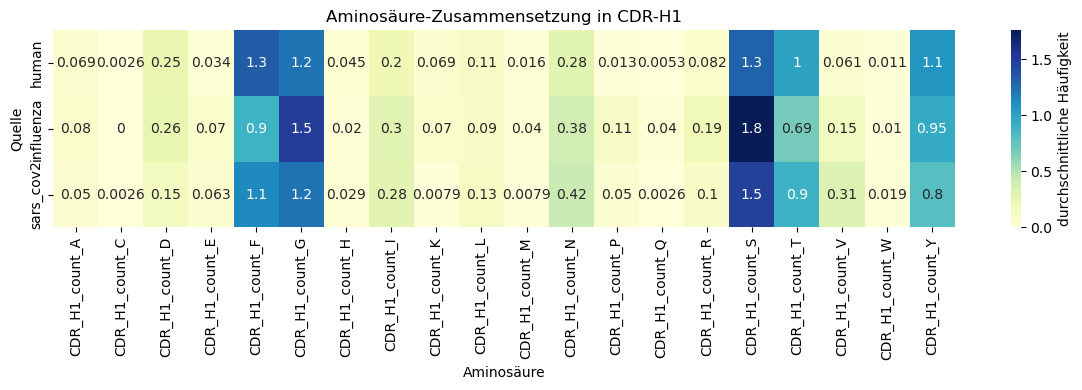

In [ ]:
#Heatmap zur Aminosäurehäufigkeit (CDR_H1)

import seaborn as sns
import matplotlib.pyplot as plt

# Dateien und Labels
dateien = {
    "human": "human_cdr_seq.tsv",
    "sars_cov2": "sars_cov2_cdr_seq.tsv",
    "influenza": "influenza_cdr_seq.tsv"
}

# Ergebnisse speichern
df_list = []

for quelle, path in dateien.items():
    df = pd.read_csv(path, sep="\t")
    
    # Nur CDR_H3-Count-Spalten auswählen
    aa_counts = df[[col for col in df.columns if col.startswith('CDR_H1_count_')]].copy()
    aa_counts['quelle'] = quelle
    df_list.append(aa_counts)

# Zusammenführen
df_all = pd.concat(df_list)

# Gruppieren und Mittelwerte berechnen
heatmap_data = df_all.groupby('quelle').mean()

# Spalten alphabetisch sortieren
heatmap_data = heatmap_data[sorted(heatmap_data.columns)]

# Plot
plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", cbar_kws={"label": "durchschnittliche Häufigkeit"})
plt.title("Aminosäure-Zusammensetzung in CDR-H1")
plt.xlabel("Aminosäure")
plt.ylabel("Quelle")
plt.tight_layout()
plt.show()
